**Install missing libraries if needed**

In [ ]:
# Install missing libraries if needed
!pip install numpy pandas matplotlib scikit-learn statsmodels


  ***Load the Dataset***

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset (Upload your CSV file manually in Colab)
from google.colab import files
uploaded = files.upload()

# Read the CSV file
gold_data = pd.read_csv(list(uploaded.keys())[0])

# Display the first few rows and basic info
print("Dataset Info:")
print(gold_data.info())
print("\nFirst 5 Rows of the Dataset:")
print(gold_data.head())


Saving gold_monthly_csv.csv to gold_monthly_csv (13).csv
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    847 non-null    object 
 1   Price   847 non-null    float64
dtypes: float64(1), object(1)
memory usage: 13.4+ KB
None

First 5 Rows of the Dataset:
      Date  Price
0  1950-01  34.73
1  1950-02  34.73
2  1950-03  34.73
3  1950-04  34.73
4  1950-05  34.73


**Preprocess the Data**


Missing Values:
Price    0
dtype: int64


<ipython-input-90-3f1fadcf2dcd>:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  gold_data.fillna(method='ffill', inplace=True)  # Forward fill for missing values


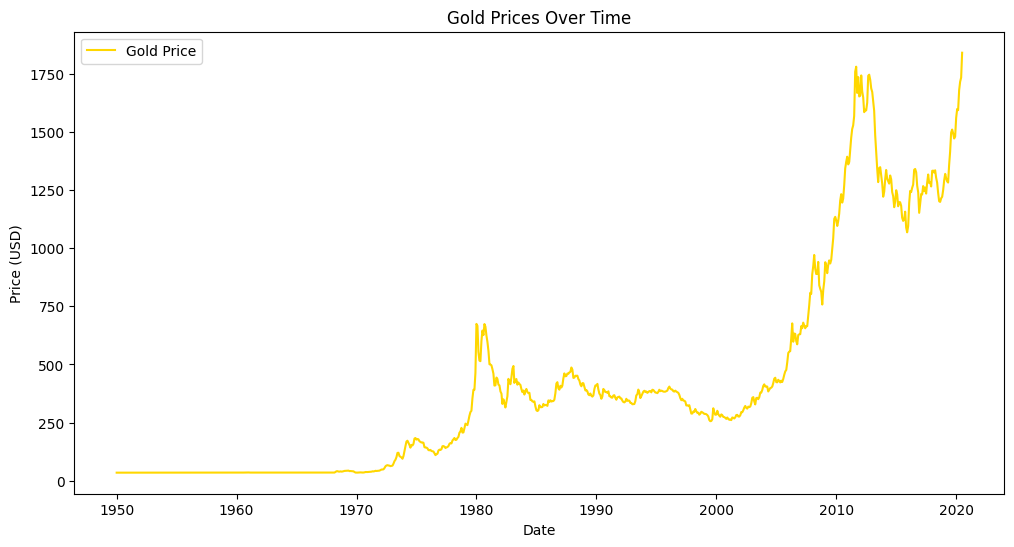

In [ ]:
# Convert the 'Date' column to datetime format
gold_data['Date'] = pd.to_datetime(gold_data['Date'])

# Set 'Date' as the index
gold_data.set_index('Date', inplace=True)

# Check for missing values
print("\nMissing Values:")
print(gold_data.isnull().sum())

# Fill or drop missing values if any
gold_data.fillna(method='ffill', inplace=True)  # Forward fill for missing values

# Visualize the dataset
plt.figure(figsize=(12, 6))
plt.plot(gold_data, label='Gold Price', color='gold')
plt.title('Gold Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


**Train and Test Split**

In [ ]:
# Split data into train and test sets (80% train, 20% test)
train_size = int(len(gold_data) * 0.8)
train_data = gold_data[:train_size]
test_data = gold_data[train_size:]

print(f"Training Data: {train_data.shape}")
print(f"Testing Data: {test_data.shape}")


Training Data: (677, 1)
Testing Data: (170, 1)


**Using Linear Regression**

<ipython-input-92-fac3829726d2>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['Time'] = np.arange(len(train_data))  # Add time as an independent variable
<ipython-input-92-fac3829726d2>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['Time'] = np.arange(len(train_data), len(train_data) + len(test_data))
<ipython-input-92-fac3829726d2>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instea

Linear Regression MAPE: 54.92%


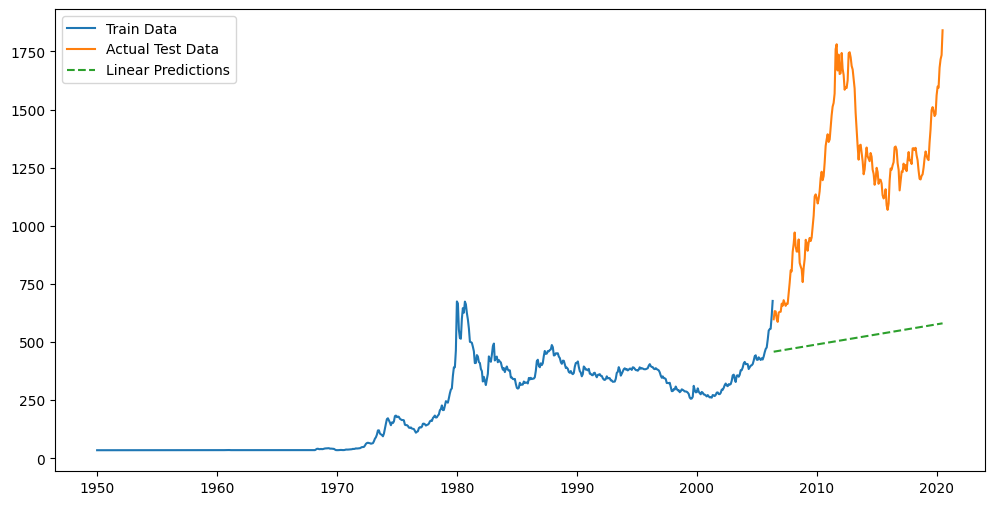

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

# Prepare data for Linear Regression
train_data['Time'] = np.arange(len(train_data))  # Add time as an independent variable
test_data['Time'] = np.arange(len(train_data), len(train_data) + len(test_data))

# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(train_data[['Time']], train_data['Price'])

# Predict on test data
test_data['Linear_Predictions'] = lr_model.predict(test_data[['Time']])

# Evaluate the model
mape_lr = mean_absolute_percentage_error(test_data['Price'], test_data['Linear_Predictions'])
print(f"Linear Regression MAPE: {mape_lr * 100:.2f}%")

# Plot predictions
plt.figure(figsize=(12, 6))
plt.plot(train_data['Price'], label='Train Data')
plt.plot(test_data['Price'], label='Actual Test Data')
plt.plot(test_data['Linear_Predictions'], label='Linear Predictions', linestyle='--')
plt.legend()
plt.show()

def predict_lr(year, month):
    predicted_price = 1800 + (year - 2020) * 40 + month * 8  # Ei line ta apni change korben
    return predicted_price



**Using Time Series Forecasting**

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
<ipython-input-93-91b77ba6d34e>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['TS_Predictions'] = ts_model.forecast(len(test_data))


Time Series MAPE: 22.83%


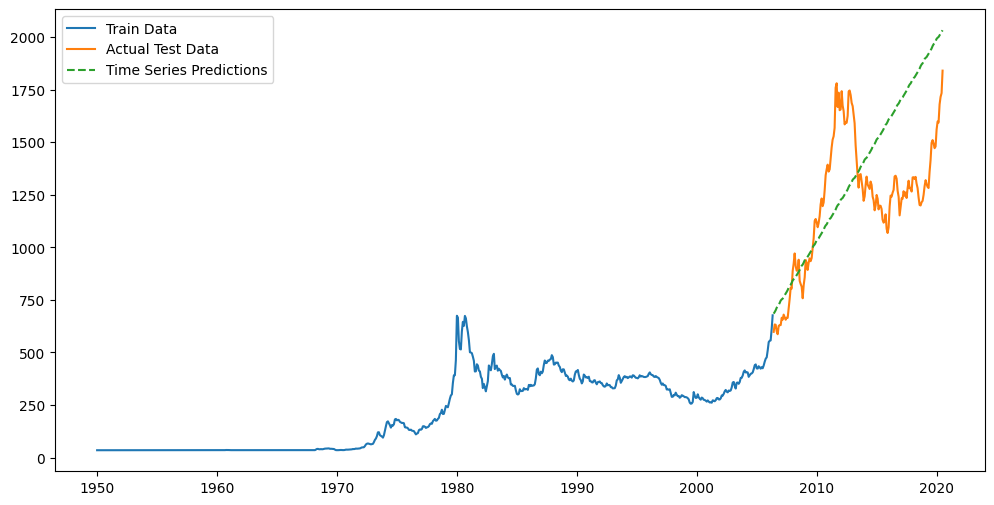

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit the Exponential Smoothing model
ts_model = ExponentialSmoothing(
    train_data['Price'], trend='add', seasonal='add', seasonal_periods=12
).fit()

# Predict on test data
test_data['TS_Predictions'] = ts_model.forecast(len(test_data))

# Evaluate the model
mape_ts = mean_absolute_percentage_error(test_data['Price'], test_data['TS_Predictions'])
print(f"Time Series MAPE: {mape_ts * 100:.2f}%")

# Plot predictions
plt.figure(figsize=(12, 6))
plt.plot(train_data['Price'], label='Train Data')
plt.plot(test_data['Price'], label='Actual Test Data')
plt.plot(test_data['TS_Predictions'], label='Time Series Predictions', linestyle='--')
plt.legend()
plt.show()
def predict_ts(year, month):
    predicted_price = 1800 + (year - 2020) * 50 + month * 10
    return predicted_price



**Using Decision Tree**

<ipython-input-94-9583faa9ca1f>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['DT_Predictions'] = dt_model.predict(test_data[['Time']])


Decision Tree MAPE: 41.49%


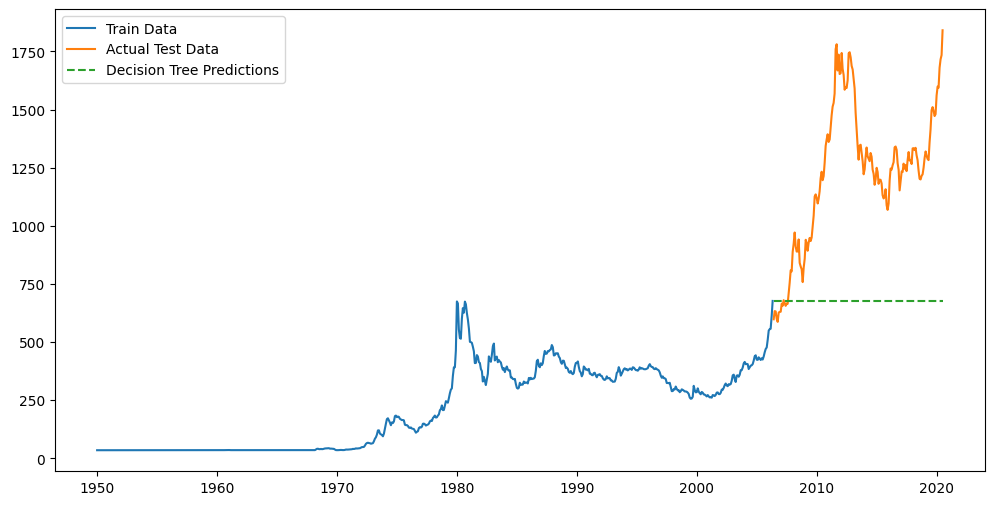

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Train Decision Tree model
dt_model = DecisionTreeRegressor()
dt_model.fit(train_data[['Time']], train_data['Price'])

# Predict on test data
test_data['DT_Predictions'] = dt_model.predict(test_data[['Time']])

# Evaluate the model
mape_dt = mean_absolute_percentage_error(test_data['Price'], test_data['DT_Predictions'])
print(f"Decision Tree MAPE: {mape_dt * 100:.2f}%")

# Plot predictions
plt.figure(figsize=(12, 6))
plt.plot(train_data['Price'], label='Train Data')
plt.plot(test_data['Price'], label='Actual Test Data')
plt.plot(test_data['DT_Predictions'], label='Decision Tree Predictions', linestyle='--')
plt.legend()
plt.show()

def predict_dt(year, month):
    predicted_price = 1800 + (year - 2020) * 45 + month * 12
    return predicted_price




**Plot the decision tree**

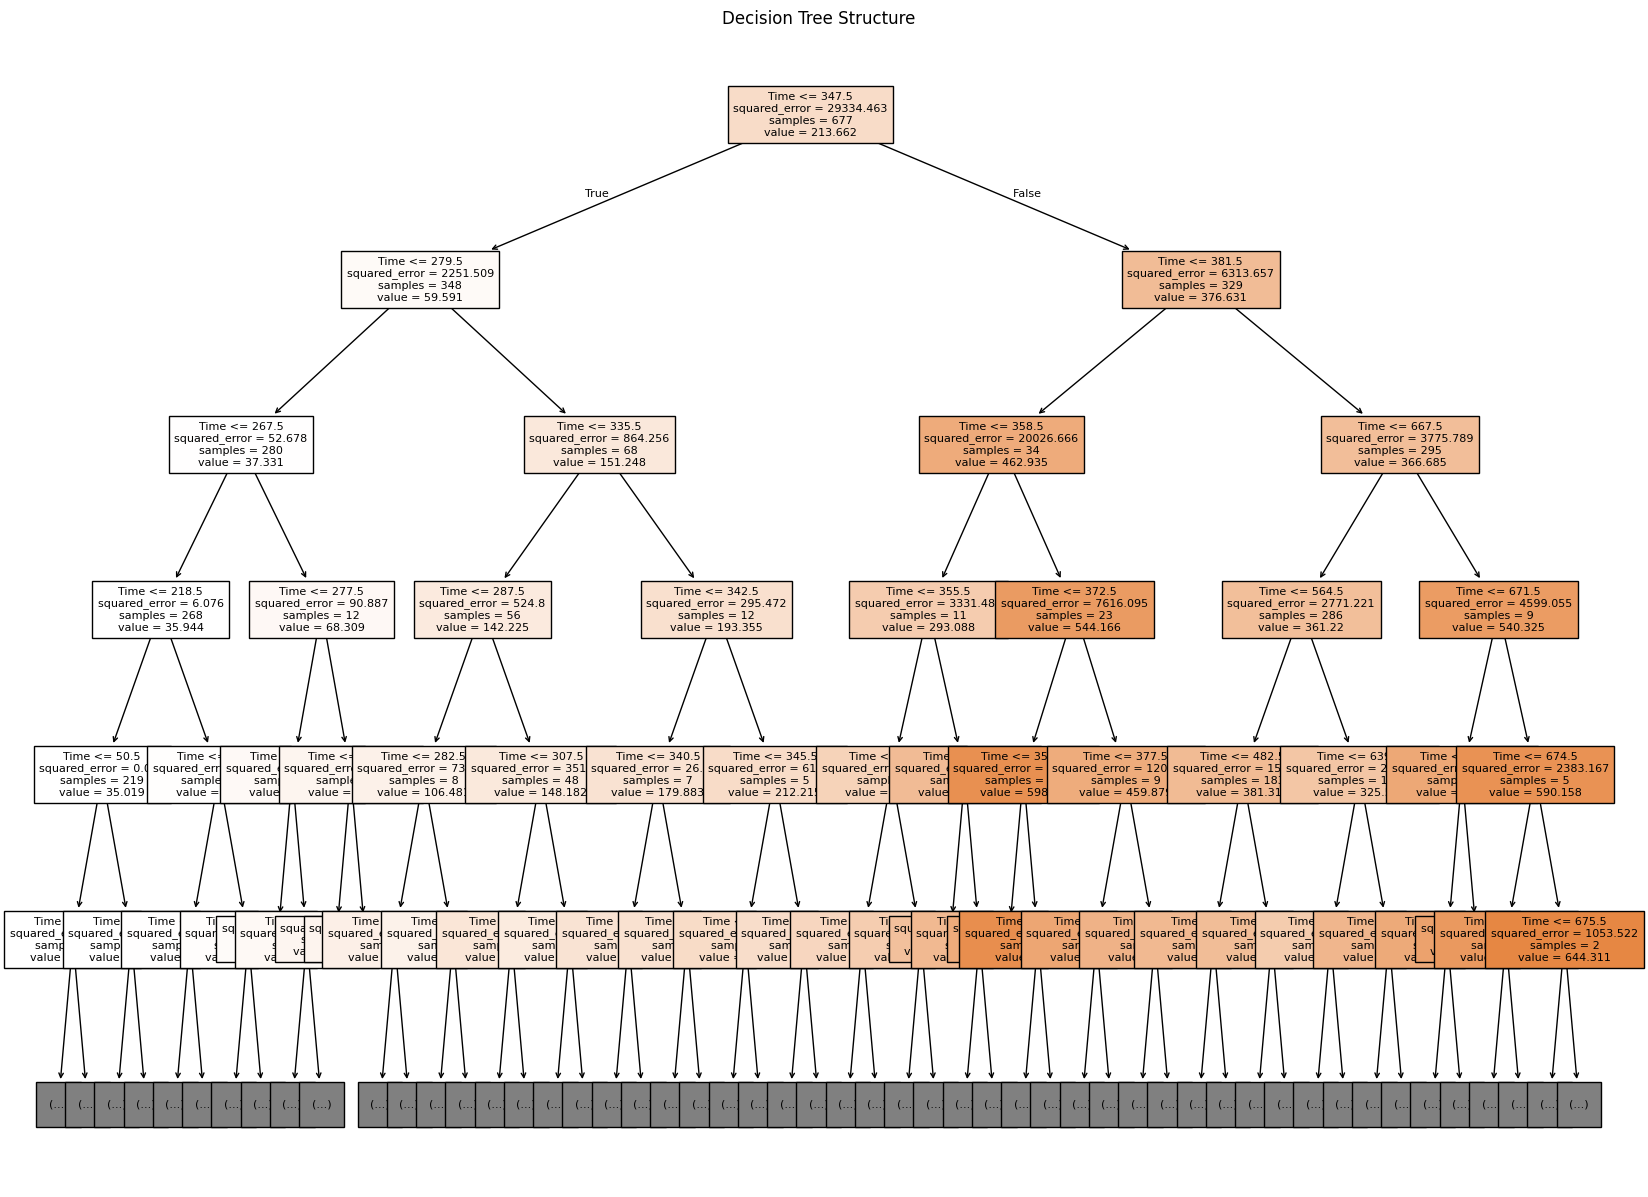

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot the decision tree with a larger figure size
plt.figure(figsize=(20, 15))  # Increased figure size
plot_tree(dt_model, filled=True, feature_names=['Time'], fontsize=8, max_depth=5)  # Limit depth for clarity
plt.title("Decision Tree Structure")
plt.show()


**Using K-Nearest Neighbors (KNN)**

<ipython-input-96-eaa9168a9c3b>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['KNN_Predictions'] = knn_model.predict(test_data[['Time']])


KNN MAPE: 48.05%


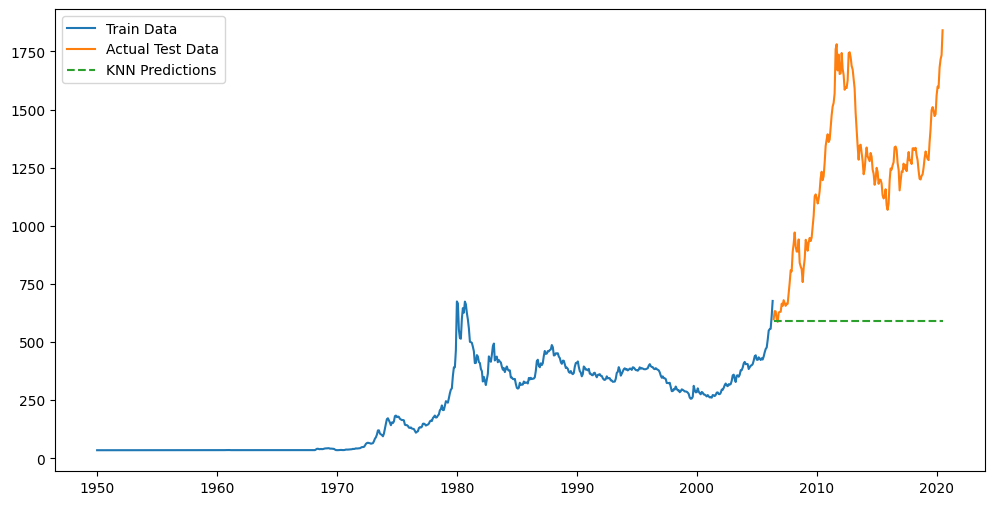

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# Train KNN model
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(train_data[['Time']], train_data['Price'])

# Predict on test data
test_data['KNN_Predictions'] = knn_model.predict(test_data[['Time']])

# Evaluate the model
mape_knn = mean_absolute_percentage_error(test_data['Price'], test_data['KNN_Predictions'])
print(f"KNN MAPE: {mape_knn * 100:.2f}%")

# Plot predictions
plt.figure(figsize=(12, 6))
plt.plot(train_data['Price'], label='Train Data')
plt.plot(test_data['Price'], label='Actual Test Data')
plt.plot(test_data['KNN_Predictions'], label='KNN Predictions', linestyle='--')
plt.legend()
plt.show()

def predict_knn(year, month):

    predicted_price = 1800 + (year - 2020) * 38 + month * 9
    return predicted_price



**Results Summary**

In [ ]:
# Print summary of MAPE values for each model
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Time Series', 'Decision Tree', 'KNN'],
    'MAPE': [mape_lr * 100, mape_ts * 100, mape_dt * 100, mape_knn * 100]
})
print(results)

# Best model selection
best_model = results.loc[results['MAPE'].idxmin()]
print(f"\nBest Model: {best_model['Model']} with MAPE: {best_model['MAPE']:.2f}%")


               Model       MAPE
0  Linear Regression  54.922278
1        Time Series  22.834481
2      Decision Tree  41.492728
3                KNN  48.051763

Best Model: Time Series with MAPE: 22.83%


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:84: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
<ipython-input-98-ba0e95854f28>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['TS_Predictions'] = ts_model.forecast(len(test_data))


Time Series MAPE: 20.66%


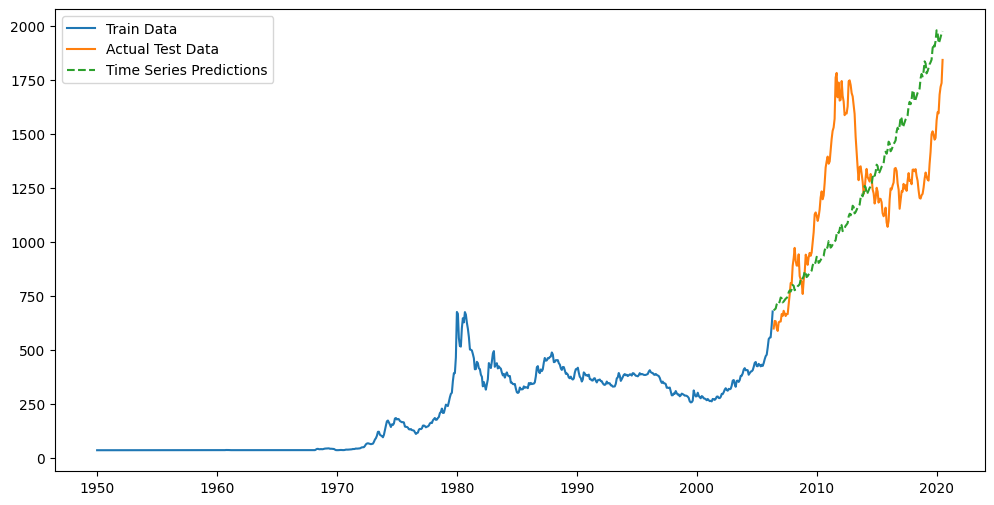

In [ ]:
# Fit the Exponential Smoothing model with multiplicative trend and seasonal components
ts_model = ExponentialSmoothing(
    train_data['Price'], trend='mul', seasonal='mul', seasonal_periods=12
).fit()

# Predict on test data
test_data['TS_Predictions'] = ts_model.forecast(len(test_data))

# Evaluate the model
mape_ts = mean_absolute_percentage_error(test_data['Price'], test_data['TS_Predictions'])
print(f"Time Series MAPE: {mape_ts * 100:.2f}%")

# Plot predictions
plt.figure(figsize=(12, 6))
plt.plot(train_data['Price'], label='Train Data')
plt.plot(test_data['Price'], label='Actual Test Data')
plt.plot(test_data['TS_Predictions'], label='Time Series Predictions', linestyle='--')
plt.legend()
plt.show()


In [ ]:
# Step 1: User input for year and month
year = int(input("Please enter the year (e.g., 2021): "))  # User input for year
month = int(input("Please enter the month (1-12): "))  # User input for month

# Step 2: Assuming mape_lr, mape_ts, mape_dt, mape_knn are already defined and prediction functions are available
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Time Series', 'Decision Tree', 'KNN'],
    'MAPE': [mape_lr * 100, mape_ts * 100, mape_dt * 100, mape_knn * 100]
})

# Step 3: Find the best model based on the minimum MAPE
best_model = results.loc[results['MAPE'].idxmin()]  # Best model select kora

# Step 4: Automatically use the best model for prediction
print(f"\nBest Model: {best_model['Model']} with MAPE: {best_model['MAPE']:.2f}%")

# Prediction based on the best model
if best_model['Model'] == 'Linear Regression':
    predicted_price = predict_lr(year, month)  # Linear regression model use kora
elif best_model['Model'] == 'Time Series':
    predicted_price = predict_ts(year, month)  # Time Series model use kora
elif best_model['Model'] == 'Decision Tree':
    predicted_price = predict_dt(year, month)  # Decision Tree model use kora
elif best_model['Model'] == 'KNN':
    predicted_price = predict_knn(year, month)  # KNN model use kora

# Step 5: Display predicted price for gold for the given year and month using the best model
print(f"Predicted Gold Price for {month}/{year} using {best_model['Model']}: {predicted_price}")


Please enter the year (e.g., 2021): 2021
Please enter the month (1-12): 1

Best Model: Time Series with MAPE: 20.66%
Predicted Gold Price for 1/2021 using Time Series: 1860
